# `LLM_ANSWERABILITY_RESULTS_validate.ipynb`

**Pipeline step:** Step 5b — Answerability Classification Analysis 
**Parquet:** `LLM_ANSWERABILITY_RESULTS_BASE.parquet` 
**Model:** `google/flan-t5-base` (250M) 
**Status:** Large results pending — see commented paths in Cell 1

---

Validates and analyzes FLAN-T5-base answerability classification results. Covers:

- **Cell 1 — Setup:** imports, paths, staleness check
- **Cell 2 — Distribution analysis:** oracle vs predicted label distributions; single-class collapse visualization
- **Cell 3 — Baseline comparison:** accuracy, macro F1, and per-class precision/recall/F1 against a majority-class baseline; variant-type breakdown with per-variant local baseline
- **Cell 4 — Confusion matrix:** 3×3 confusion matrix (count + row-normalized %) and variant-type accuracy figure
- **Cell 5 — Failure structure:** accuracy by city; oracle label × variant type cross-tab confirming zero sensitivity to spatial constraint satisfiability across all masking conditions; key findings summary

---

> **Note:** The majority-class baseline per variant type uses the *local* majority class for that variant,
> not the global majority (Contradictory). This is necessary because oracle label distributions differ
> substantially by masking type — `mask_directions` is 87–92% Ambiguous, making Ambiguous the correct
> local majority for that variant.


In [1]:
# ============================================================
# CELL 1 — Imports and setup
# ============================================================
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display
import itertools
import os
import sys
sys.path.append('..')

# Publication style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

CITIES = ['manhattan', 'pittsburgh', 'philadelphia']
CITY_COLORS    = {'manhattan': '#2196F3', 'pittsburgh': '#FF9800', 'philadelphia': '#4CAF50'}
LABEL_COLORS   = {'Answerable': '#4CAF50', 'Ambiguous': '#FF9800', 'Contradictory': '#F44336'}
VARIANT_COLORS = {'mask_landmark': '#9C27B0', 'mask_directions': '#2196F3', 'mask_both': '#FF5722'}
LABELS_ORDER   = ['Answerable', 'Ambiguous', 'Contradictory']

BASE_DIR    = os.path.abspath(os.path.join(os.path.dirname(__file__)
              if '__file__' in dir() else os.getcwd(), '..'))
REPORTS_DIR = os.path.join(BASE_DIR, 'reports', 'llm_audits')
DATA_DIR    = os.path.join(BASE_DIR, 'data')

ANSWERABILITY_BASE_PATH  = os.path.join(REPORTS_DIR, 'LLM_ANSWERABILITY_RESULTS_BASE.parquet')
# ANSWERABILITY_LARGE_PATH = os.path.join(REPORTS_DIR, 'LLM_ANSWERABILITY_RESULTS_LARGE.parquet')  # uncomment when ready

os.makedirs(f'{REPORTS_DIR}/figures', exist_ok=True)

# ── Staleness check ──────────────────────────────────────────
for label, path in [('ANSWERABILITY BASE', ANSWERABILITY_BASE_PATH)]:
    if os.path.exists(path):
        mtime = os.path.getmtime(path)
        ts    = pd.Timestamp(mtime, unit='s', tz='UTC').strftime('%Y-%m-%d %H:%M:%S UTC')
        size  = os.path.getsize(path) / 1024
        print(f'📄 {label}: {path}')
        print(f'   modified={ts}  size={size:.1f} KB')
    else:
        print(f'❌ {label} NOT FOUND: {path}')

print('\n✅ Setup complete')


📄 ANSWERABILITY BASE: /vol/joberant_nobck/data/NLP_368307701_2526a/adanassi/nlp-allocentric-spatial-reasoning/reports/llm_audits/LLM_ANSWERABILITY_RESULTS_BASE.parquet
   modified=2026-05-02 01:52:46 UTC  size=1167.9 KB

✅ Setup complete


DATASET OVERVIEW
  Total samples : 21,049
  Cities        : ['manhattan', 'pittsburgh', 'philadelphia']
  Variant types : ['mask_landmark', 'mask_directions', 'mask_both']

ORACLE LABEL DISTRIBUTION (ground truth)
  Answerable     :  3,850  (18.3%)
  Ambiguous      :  8,169  (38.8%)
  Contradictory  :  9,030  (42.9%)

PREDICTED LABEL DISTRIBUTION (model output)
  Answerable     : 20,975  (99.6%)
  Ambiguous      :      1  (0.0%)
  Contradictory  :     73  (0.3%)



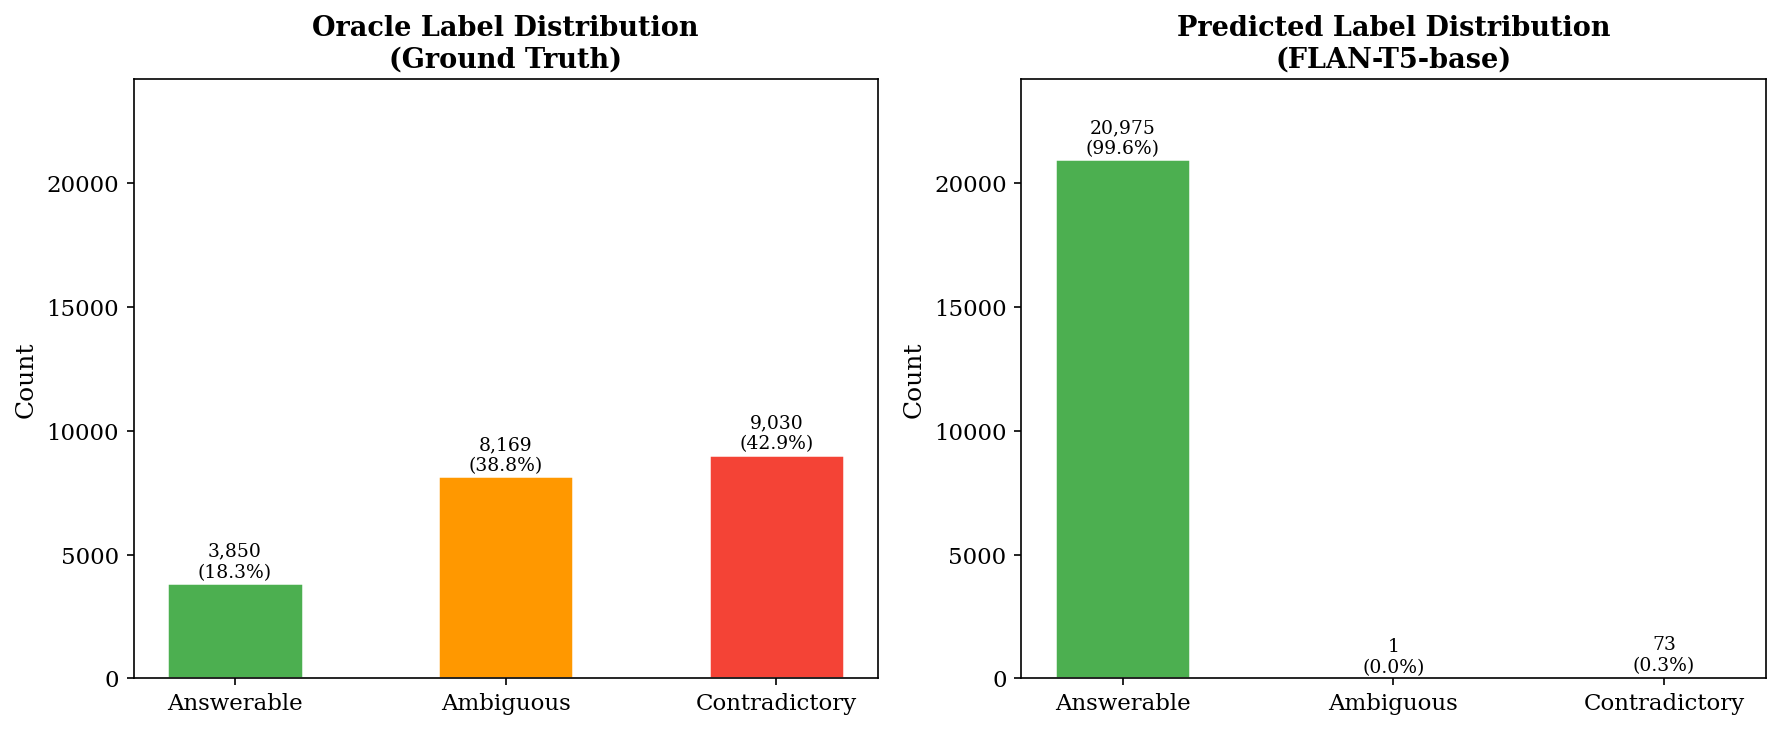

✅ Figure 1: Label distributions saved


In [2]:
# ============================================================
# CELL 2 — Dataset overview: oracle label and predicted label distributions
# ============================================================

if not os.path.exists(ANSWERABILITY_BASE_PATH):
    print('⚠️  ANSWERABILITY_BASE not found')
else:
    cls_df = pd.read_parquet(ANSWERABILITY_BASE_PATH)

    print('DATASET OVERVIEW')
    print('='*60)
    print(f'  Total samples : {len(cls_df):,}')
    print(f'  Cities        : {cls_df["city"].unique().tolist()}')
    print(f'  Variant types : {cls_df["variant_type"].unique().tolist()}')
    print()

    print('ORACLE LABEL DISTRIBUTION (ground truth)')
    print('='*60)
    for label in LABELS_ORDER:
        n   = (cls_df['oracle_label'] == label).sum()
        pct = n / len(cls_df)
        print(f'  {label:<15}: {n:>6,}  ({pct:.1%})')
    print()

    print('PREDICTED LABEL DISTRIBUTION (model output)')
    print('='*60)
    for label in LABELS_ORDER:
        n   = (cls_df['predicted_label'] == label).sum()
        pct = n / len(cls_df)
        print(f'  {label:<15}: {n:>6,}  ({pct:.1%})')
    print()

    # Distribution figure
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, col, title in [
        (axes[0], 'oracle_label',    'Oracle Label Distribution\n(Ground Truth)'),
        (axes[1], 'predicted_label', 'Predicted Label Distribution\n(FLAN-T5-base)'),
    ]:
        counts = cls_df[col].value_counts().reindex(LABELS_ORDER, fill_value=0)
        bars   = ax.bar(LABELS_ORDER, counts.values,
                        color=[LABEL_COLORS[l] for l in LABELS_ORDER],
                        edgecolor='white', linewidth=1.2, width=0.5)
        for bar, val in zip(bars, counts.values):
            pct = val / len(cls_df)
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                    f'{val:,}\n({pct:.1%})', ha='center', va='bottom', fontsize=9)
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel('Count')
        ax.set_ylim(0, len(cls_df) * 1.15)

    plt.tight_layout()
    plt.savefig(f'{REPORTS_DIR}/figures/answerability_label_distributions.png')
    plt.show()
    print('✅ Figure 1: Label distributions saved')


In [3]:
# ============================================================
# CELL 3 — Majority-class baseline + model accuracy
# ============================================================

if not os.path.exists(ANSWERABILITY_BASE_PATH):
    print('⚠️  ANSWERABILITY_BASE not found')
else:
    cls_df = pd.read_parquet(ANSWERABILITY_BASE_PATH)

    # ── Majority-class baseline ───────────────────────────────────────────
    majority_class = cls_df['oracle_label'].value_counts().idxmax()
    majority_pct   = cls_df['oracle_label'].value_counts(normalize=True).max()
    baseline_preds = [majority_class] * len(cls_df)

    baseline_acc    = (cls_df['oracle_label'] == majority_class).mean()
    baseline_report = classification_report(
        cls_df['oracle_label'], baseline_preds,
        labels=LABELS_ORDER, output_dict=True, zero_division=0
    )
    baseline_macro_f1 = baseline_report['macro avg']['f1-score']

    # ── Model results ─────────────────────────────────────────────────────
    model_acc    = cls_df['is_correct'].mean()
    model_report = classification_report(
        cls_df['oracle_label'], cls_df['predicted_label'],
        labels=LABELS_ORDER, output_dict=True, zero_division=0
    )
    model_macro_f1 = model_report['macro avg']['f1-score']

    # ── Print comparison ──────────────────────────────────────────────────
    print('CLASSIFICATION RESULTS: Model vs Majority-Class Baseline')
    print('='*60)
    print(f'  Majority class     : {majority_class} ({majority_pct:.1%} of labels)')
    print()
    print(f'{"System":<30} {"Accuracy":>10} {"Macro F1":>10}')
    print('-'*52)
    print(f'{"Majority-class baseline":<30} {baseline_acc*100:>9.1f}% {baseline_macro_f1:>10.3f}')
    print(f'{"FLAN-T5-base (250M)":<30} {model_acc*100:>9.1f}% {model_macro_f1:>10.3f}')
    print(f'{"FLAN-T5-large (780M)":<30} {"[pending]":>10} {"[pending]":>10}')
    print()
    print(f'  Δ accuracy  (model - baseline): {(model_acc - baseline_acc)*100:+.1f}pp')
    print(f'  Δ macro F1  (model - baseline): {(model_macro_f1 - baseline_macro_f1):+.3f}')
    print()

    print('PER-CLASS RESULTS')
    print('='*60)
    print(f'{"Label":<15} {"":^25} {"Baseline":^25} {"FLAN-T5-base":^25}')
    print(f'{"":<15} {"P":>8} {"R":>8} {"F1":>8} {"P":>8} {"R":>8} {"F1":>8} {"N":>6}')
    print('-'*75)
    for label in LABELS_ORDER:
        bp = baseline_report[label]['precision']
        br = baseline_report[label]['recall']
        bf = baseline_report[label]['f1-score']
        mp = model_report[label]['precision']
        mr = model_report[label]['recall']
        mf = model_report[label]['f1-score']
        n  = model_report[label]['support']
        print(f'{label:<15} {bp:>8.2f} {br:>8.2f} {bf:>8.2f} {mp:>8.2f} {mr:>8.2f} {mf:>8.2f} {n:>6}')
    print()

    print('ACCURACY BY VARIANT TYPE')
    print('='*60)
    print(f'{"Variant":<22} {"Baseline":>10} {"Model":>10} {"Delta":>8}')
    print('-'*52)
    for vtype in ['mask_landmark', 'mask_directions', 'mask_both']:
        sub        = cls_df[cls_df['variant_type'] == vtype]
        maj_v      = sub['oracle_label'].value_counts().idxmax()
        baseline_v = (sub['oracle_label'] == maj_v).mean()
        model_v    = sub['is_correct'].mean()
        delta      = (model_v - baseline_v) * 100
        print(f'{vtype:<22} {baseline_v*100:>9.1f}% {model_v*100:>9.1f}% {delta:>+7.1f}pp')
    print()
    print('Note: baseline per variant uses that variant\'s local majority class,')
    print('not the global majority, because oracle label distributions differ by variant type.')


CLASSIFICATION RESULTS: Model vs Majority-Class Baseline
  Majority class     : Contradictory (42.9% of labels)

System                           Accuracy   Macro F1
----------------------------------------------------
Majority-class baseline             42.9%      0.200
FLAN-T5-base (250M)                 18.4%      0.105
FLAN-T5-large (780M)            [pending]  [pending]

  Δ accuracy  (model - baseline): -24.5pp
  Δ macro F1  (model - baseline): -0.095

PER-CLASS RESULTS
Label                                             Baseline                FLAN-T5-base       
                       P        R       F1        P        R       F1      N
---------------------------------------------------------------------------
Answerable          0.00     0.00     0.00     0.18     1.00     0.31 3850.0
Ambiguous           0.00     0.00     0.00     1.00     0.00     0.00 8169.0
Contradictory       0.43     1.00     0.60     0.27     0.00     0.00 9030.0

ACCURACY BY VARIANT TYPE
Variant        

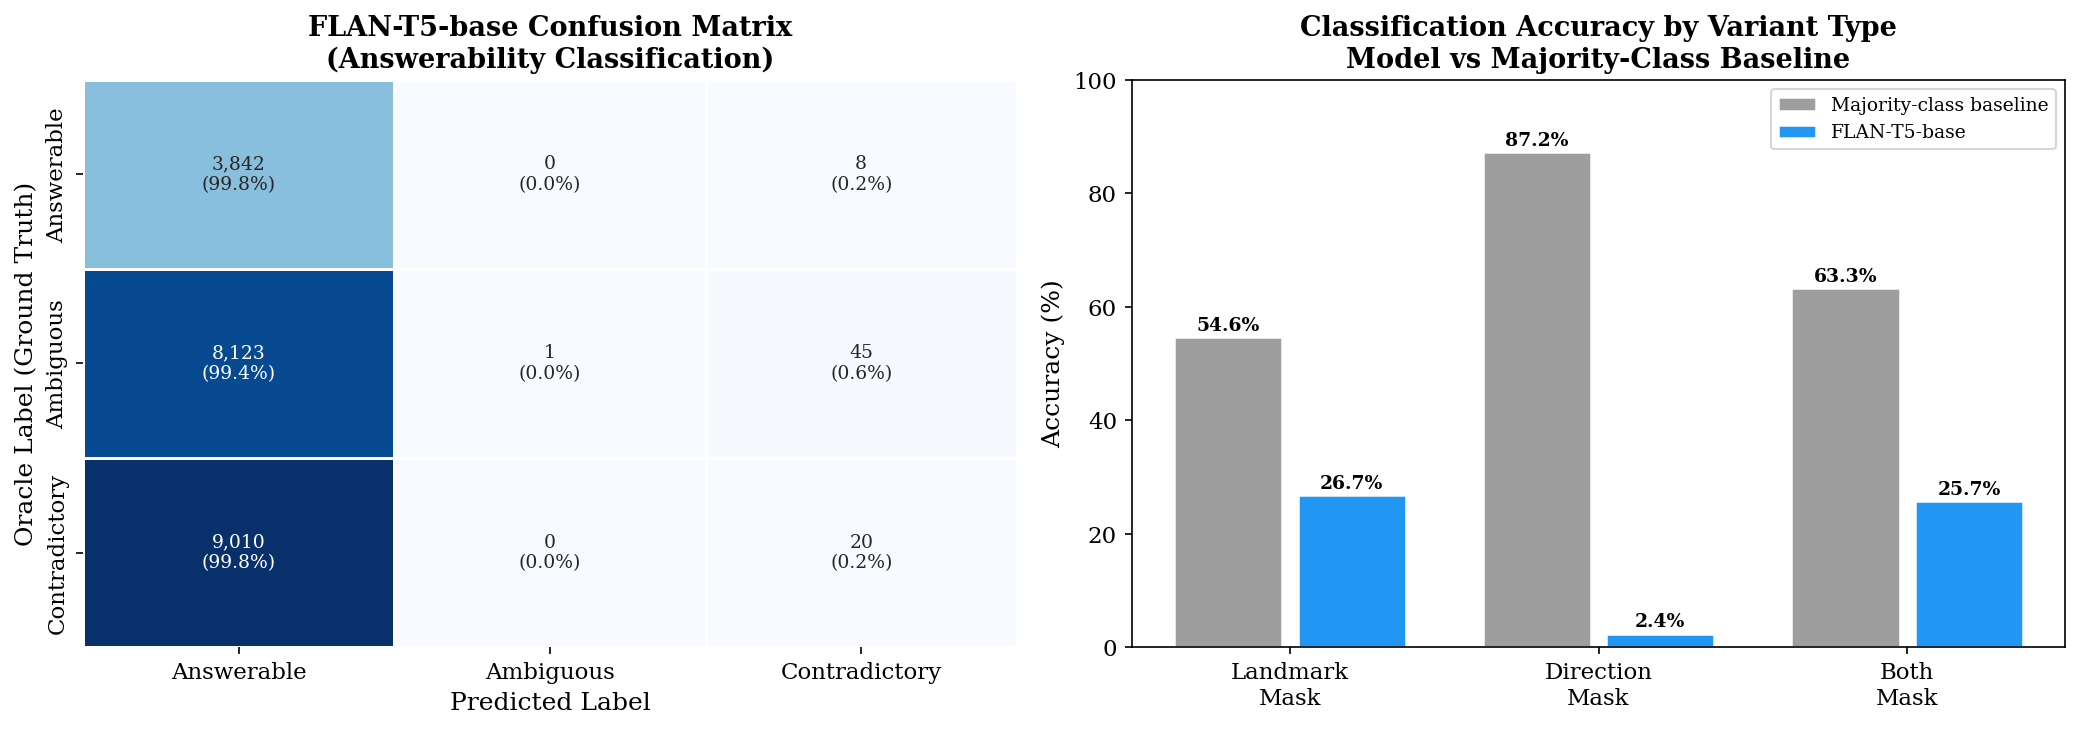

✅ Figure 2: Confusion matrix + variant accuracy saved


In [4]:
# ============================================================
# CELL 4 — Confusion matrix + variant-type accuracy figure
# ============================================================

if not os.path.exists(ANSWERABILITY_BASE_PATH):
    print('⚠️  ANSWERABILITY_BASE not found')
else:
    cls_df = pd.read_parquet(ANSWERABILITY_BASE_PATH)
    majority_class = cls_df['oracle_label'].value_counts().idxmax()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Confusion matrix ──────────────────────────────────────────────────
    ax = axes[0]
    cm = confusion_matrix(
        cls_df['oracle_label'], cls_df['predicted_label'],
        labels=LABELS_ORDER
    )
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    annot  = [[f'{cm[i,j]:,}\n({cm_pct[i,j]:.1%})'
                for j in range(3)] for i in range(3)]
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=LABELS_ORDER, yticklabels=LABELS_ORDER,
                linewidths=0.5, cbar=False, annot_kws={'size': 9})
    ax.set_title('FLAN-T5-base Confusion Matrix\n(Answerability Classification)',
                 fontweight='bold')
    ax.set_ylabel('Oracle Label (Ground Truth)')
    ax.set_xlabel('Predicted Label')

    # ── Variant-type accuracy: model vs baseline ──────────────────────────
    ax = axes[1]
    vtypes       = ['mask_landmark', 'mask_directions', 'mask_both']
    vtype_labels = ['Landmark\nMask', 'Direction\nMask', 'Both\nMask']
    x = np.arange(len(vtypes))

    baseline_accs = []
    model_accs    = []
    for vtype in vtypes:
        sub = cls_df[cls_df['variant_type'] == vtype]
        maj = sub['oracle_label'].value_counts().idxmax()
        baseline_accs.append((sub['oracle_label'] == maj).mean() * 100)
        model_accs.append(sub['is_correct'].mean() * 100)

    bars1 = ax.bar(x - 0.2, baseline_accs, 0.35,
                   label='Majority-class baseline',
                   color='#9E9E9E', edgecolor='white', linewidth=1.2)
    bars2 = ax.bar(x + 0.2, model_accs, 0.35,
                   label='FLAN-T5-base',
                   color='#2196F3', edgecolor='white', linewidth=1.2)
    for bar, val in itertools.chain(zip(bars1, baseline_accs), zip(bars2, model_accs)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(vtype_labels)
    ax.set_ylim(0, 100)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Classification Accuracy by Variant Type\nModel vs Majority-Class Baseline',
                 fontweight='bold')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{REPORTS_DIR}/figures/answerability_classification_results.png')
    plt.show()
    print('✅ Figure 2: Confusion matrix + variant accuracy saved')


In [5]:
# ============================================================
# CELL 5 — Accuracy by city and oracle label
# ============================================================

if not os.path.exists(ANSWERABILITY_BASE_PATH):
    print('⚠️  ANSWERABILITY_BASE not found')
else:
    cls_df = pd.read_parquet(ANSWERABILITY_BASE_PATH)

    print('ACCURACY BY CITY')
    print('='*60)
    print(f'{"City":<15} {"N":>6} {"Accuracy":>10} {"Macro F1":>10}')
    print('-'*45)
    for city in CITIES:
        sub  = cls_df[cls_df['city'] == city]
        acc  = sub['is_correct'].mean()
        rep  = classification_report(
            sub['oracle_label'], sub['predicted_label'],
            labels=LABELS_ORDER, output_dict=True, zero_division=0
        )
        mf1  = rep['macro avg']['f1-score']
        print(f'{city.capitalize():<15} {len(sub):>6,} {acc*100:>9.1f}% {mf1:>10.3f}')
    print()

    print('RESOLUTION RATE BY ORACLE LABEL × VARIANT TYPE')
    print('(resolution_succeeded = implicit Answerable prediction)')
    print('='*60)
    pivot = cls_df.groupby(['oracle_label', 'variant_type'])['is_correct'].mean().unstack('variant_type') * 100
    pivot = pivot.reindex(LABELS_ORDER)
    pivot.columns = [c.replace('_', ' ').title() for c in pivot.columns]
    display(pivot.round(1))
    print()

    # ── Key finding printout ──────────────────────────────────────────────
    model_acc      = cls_df['is_correct'].mean()
    majority_class = cls_df['oracle_label'].value_counts().idxmax()
    baseline_acc   = (cls_df['oracle_label'] == majority_class).mean()

    ans_acc  = cls_df[cls_df['oracle_label']=='Answerable']['is_correct'].mean()
    amb_acc  = cls_df[cls_df['oracle_label']=='Ambiguous']['is_correct'].mean()
    con_acc  = cls_df[cls_df['oracle_label']=='Contradictory']['is_correct'].mean()
    dir_acc  = cls_df[cls_df['variant_type']=='mask_directions']['is_correct'].mean()

    print('KEY FINDINGS')
    print('='*60)
    print(f'  Overall accuracy            : {model_acc*100:.1f}%  (baseline: {baseline_acc*100:.1f}%)')
    print(f'  Δ vs majority-class baseline: {(model_acc-baseline_acc)*100:+.1f}pp')
    print(f'  Answerable accuracy         : {ans_acc*100:.1f}%')
    print(f'  Ambiguous accuracy          : {amb_acc*100:.1f}%')
    print(f'  Contradictory accuracy      : {con_acc*100:.1f}%')
    print(f'  mask_directions accuracy    : {dir_acc*100:.1f}%')
    print(f'  Predicted Answerable rate   : {(cls_df["predicted_label"]=="Answerable").mean()*100:.1f}%')
    print(f'  Single-class collapse       : model predicts Answerable in '
          f'{(cls_df["predicted_label"]=="Answerable").sum():,}/{len(cls_df):,} cases')


ACCURACY BY CITY
City                 N   Accuracy   Macro F1
---------------------------------------------
Manhattan       16,066      22.1%      0.122
Pittsburgh       2,041       2.6%      0.018
Philadelphia     2,942       8.8%      0.055

RESOLUTION RATE BY ORACLE LABEL × VARIANT TYPE
(resolution_succeeded = implicit Answerable prediction)


,Mask Both,Mask Directions,Mask Landmark
oracle_label,,,
Answerable,99.7,99.4,99.9
Ambiguous,0.0,0.0,0.0
Contradictory,0.3,0.3,0.1



KEY FINDINGS
  Overall accuracy            : 18.4%  (baseline: 42.9%)
  Δ vs majority-class baseline: -24.5pp
  Answerable accuracy         : 99.8%
  Ambiguous accuracy          : 0.0%
  Contradictory accuracy      : 0.2%
  mask_directions accuracy    : 2.4%
  Predicted Answerable rate   : 99.6%
  Single-class collapse       : model predicts Answerable in 20,975/21,049 cases
